In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 10,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 10,
                     'lmax': 1500}

use_obs  = ['GC','WL']
choice='alpha_M'

In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 
#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}

EFT_params = {'EFTflag':0}
fiducial.update(EFT_params)
camb_path = '/users/chiaradeleo/Desktop/myeftcamb-main/' 


In [5]:
distributions = np.load('./mock_data/MG_test_galonly_IApoly_source_distribution.npy',allow_pickle=True).item()


In [6]:
if 'GC' in distributions:
    Nbins_gc=distributions['GC']['Nbins']

if 'WL' in distributions:
    Nbins_wl=distributions['WL']['Nbins']
if Nbins_gc>=Nbins_wl:
    bincolors = sb.color_palette('hls',Nbins_gc)

else:
    bincolors = sb.color_palette('hls',Nbins_wl)

In [7]:
from source_code.compute_obs_sources import get_obs
case='simple'
extra={}

In [8]:
calc_obs_LCDM = get_obs(fiducial,extra,distributions,ells,camb_path,case='simple',feedback=True)


CAMB took 5.57 s
Cls packing took 0.05 s
Cls computed in 5.9 s


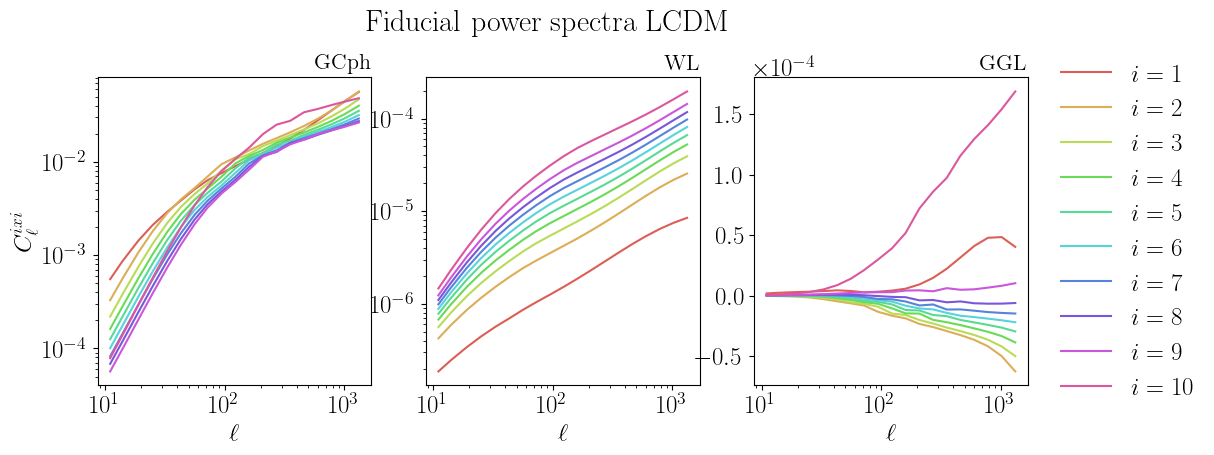

In [9]:
norm = ells*(ells+1)/(2*np.pi)

fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
plt.suptitle('Fiducial power spectra LCDM',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs_LCDM.Cls['G{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')

axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
axes[-1].legend(**sidelegend);

In [10]:
choice=1
if choice==1:
    del(fiducial)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
    EFT_params = {'EFTflag':1,
                  'PureEFTmodel':1,
                  'PureEFTmodelOmega':3,
                  'EFTOmega0':-0.019,
                  'EFTOmegaExp':0.66}
    EFT_params.update(stability_flag)


In [11]:
if choice==1:
    calc_obs_EFTflag1 = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case='simple',feedback=True)




{'EFTflag': 1, 'PureEFTmodel': 1, 'PureEFTmodelOmega': 3, 'EFTOmega0': -0.019, 'EFTOmegaExp': 0.66, 'EFT_ghost_math_stability': False, 'EFT_mass_math_stability': False, 'EFT_ghost_stability': False, 'EFT_gradient_stability': False, 'EFT_mass_stability': False, 'EFT_additional_priors': False}
CAMB took 10.22 s
Cls packing took 0.05 s
Cls computed in 10.3 s


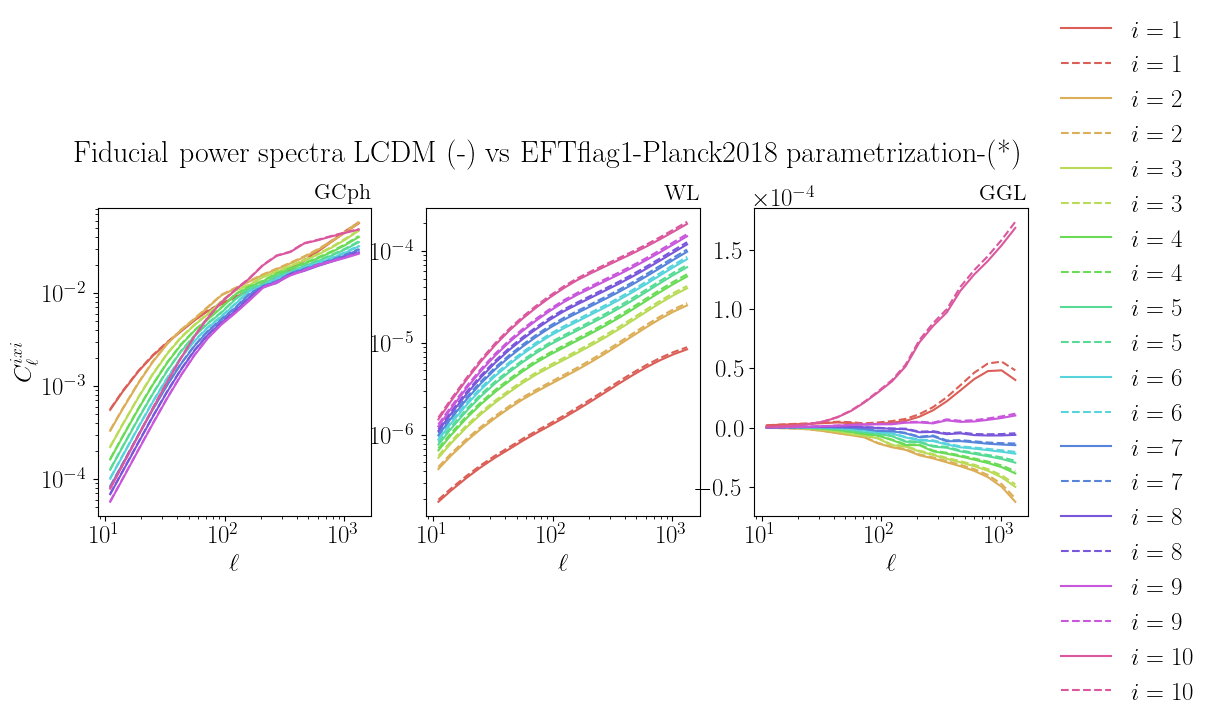

In [16]:
if choice==1:
    fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
    plt.suptitle('Fiducial power spectra LCDM (-) vs EFTflag1-Planck2018 parametrization-(*)',y=1.05)
    
    if 'GC' in use_obs:
        axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
            axes[0].plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
            axes[0].plot(ells,calc_obs_EFTflag1.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),ls='--',color=bincolors[i-1])
        axes[0].set_xlabel(r'$\ell$')
        axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        axes[0].set_xscale('log')
        axes[0].set_yscale('log')
        
    if 'WL' in use_obs:
        axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_wl+1):
            axes[1].plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
            axes[1].plot(ells,calc_obs_EFTflag1.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),ls='--',color=bincolors[i-1])
        axes[1].set_xlabel(r'$\ell$')
        axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        axes[1].set_xscale('log')
        axes[1].set_yscale('log')
        
    if 'GC' in use_obs and 'WL' in use_obs:
        axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
            axes[2].plot(ells,calc_obs_LCDM.Cls['G{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
            axes[2].plot(ells,calc_obs_EFTflag1.Cls['G{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),ls='--',color=bincolors[i-1])
        axes[2].set_xlabel(r'$\ell$')
        axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        axes[2].set_xscale('log')
    
    axes[0].set_ylabel(r'$C_\ell^{ixi}$')
    plt.subplots_adjust(hspace=1.2)
    plt.savefig('LCDM_EFTflag1.pdf', bbox_inches='tight')
    axes[-1].legend(**sidelegend);

NameError: name 'calc_obs_Sigma' is not defined

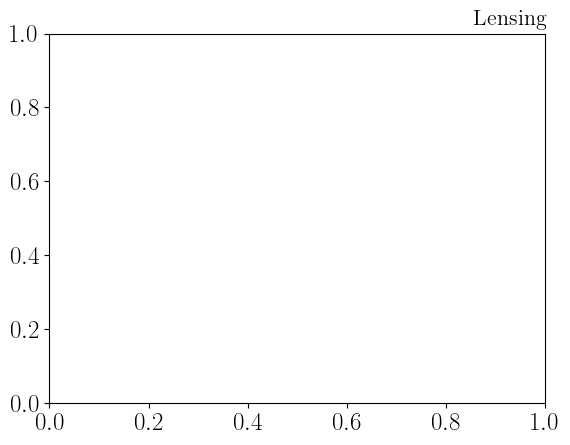

In [13]:

#plt.suptitle('Impact of $\Sigma_0$ (-) respect to LCDM (--)',y=1.05)
if choice==1:
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_Sigma.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==1:
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_Sigma.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice=='alpha_M':
    del(fiducial, EFT_params)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    EFT_params = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFT_mass_stability_rate': 14.0, 'feedback_level': 5, 'EFTCAMB_back_turn_on': 4.00000001, 
 'EFTCAMB_turn_on_time': 4.01, 'EFTCAMB_GR_threshold': 4.00000001, 'EFTCAMB_stability_time': 4.0000000001, 
 'EFTCAMB_stability_threshold': 4.0, 'RPHmassPmodel': 1, 'RPHmassP0': 5.0}
    
    
    EFT_params.update(stability_flag)

In [ ]:
if choice=='alpha_M':
    calc_obs_alpha_M = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case,feedback=True)




In [ ]:
if choice=='alpha_M':    
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_M.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--',marker='o')
             #print(calc_obs_alpha_M.Cls['L{}xL{}'.format(i,i)]-calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)])
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice=='alpha_M':
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_M.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1],ls='--', marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    del(fiducial, EFT_params)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
    EFT_params = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFT_mass_stability_rate': 10.0, 'EFTCAMB_turn_on_time': 4.01, 
                  'RPHkineticitymodel': 1, 'RPHkineticity0': 5.0}
    
    EFT_params.update(stability_flag)

In [ ]:
calc_obs_alpha_k = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case,feedback=True)



In [ ]:
if choice==2:
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_k.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_k.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    del(fiducial,EFT_params)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
    EFT_params = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFT_mass_stability_rate': 14.0, 'EFTCAMB_turn_on_time': 4.01, 
                  'RPHbraidingmodel': 1,
                  'RPHbraiding0': 3.0}
    
    EFT_params.update(stability_flag)

In [ ]:
if choice==2:
    calc_obs_alpha_B = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case,feedback=True)



In [ ]:
if choice==2:
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_B.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_B.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    del(fiducial, EFT_params)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
    EFT_params = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFT_mass_stability_rate': 14.0, 'EFTCAMB_turn_on_time': 4.01,  'RPHtensormodel': 1,
                  'RPHtensor0': 3.0}
    EFT_params.update(stability_flag)

In [ ]:
if choice==2:
    calc_obs_alpha_T = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case,feedback=True)



In [ ]:
if choice==2:
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_T.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice==2:
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha_T.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1], marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
choice='alpha'
if choice=='alpha':
    del(fiducial, EFT_params)
    fiducial = {'ombh2': 0.022445,
                'omch2': 0.1205579307,
                'ns': 0.96,
                'As': 2.12605e-09,
                'tau': 0.05,
                'H0': 67.,
                'w': -1.,
                'wa': 0.,
                'mnu': 0.06,
                'a0': - 0.007589,
                'a1' :  0.002008,
                'a2' : - 0.004127,
                'a3' :  0.002918,
                'a4' : -0.0006784,
                'omegab': 0.05,
                'sigma8': 0.84,
                'omegam' : 0.31,
                'b0_poly': 0.830703,
                'b1_poly': 1.190547,
                'b2_poly': -0.928357,
                'b3_poly': 0.423292}
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
    EFT_params_alpha = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFT_mass_stability_rate': 14.0,  'EFTCAMB_back_turn_on': 4.00000001, 
     'EFTCAMB_turn_on_time': 4.01, 'EFTCAMB_GR_threshold': 4.00000001, 'EFTCAMB_stability_time': 4.0000000001, 
     'EFTCAMB_stability_threshold': 4.0, 'RPHmassPmodel': 1, 'RPHkineticitymodel': 1, 'RPHbraidingmodel': 1, 'RPHtensormodel': 1, 
     'RPHmassP0': 3.0, 'RPHkineticity0': 3.0, 'RPHbraiding0': 3.0, 'RPHtensor0': 3.0}
    
    EFT_params_alpha.update(stability_flag)


In [ ]:
if choice=='alpha':
    calc_obs_alpha = get_obs(fiducial,EFT_params_alpha,distributions,ells,camb_path,case,feedback=True)


In [ ]:
if choice=='alpha':
    if 'WL' in use_obs:
        plt.title('Lensing',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
             plt.plot(ells,calc_obs_alpha.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
             plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1],ls='--', marker='o')
             #print(calc_obs_alpha.Cls['L{}xL{}'.format(i,i)]-calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)])
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
    
    
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);

In [ ]:
if choice=='alpha':
    if 'GC' in use_obs:
        plt.title('GCph',loc='right',fontdict={'fontsize':16})
        for i in range(1,Nbins_gc+1):
            plt.plot(ells,calc_obs_alpha.Cls['G{}xG{}'.format(i,i)]*norm,
                         label=r'$i={}$'.format(i),color=bincolors[i-1])
            plt.plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                      label=r'$i={}$'.format(i),color=bincolors[i-1],ls='--', marker='o')
        plt.xlabel(r'$\ell$')
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.xscale('log')
        plt.yscale('log')
        
        
    plt.ylabel(r'$C_\ell^{ixi}$')
    plt.legend(**sidelegend);